# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

### Sumber Dataset:
- **Nama**: Wine Quality Dataset
- **Sumber**: UCI Machine Learning Repository
- **Tipe**: Structured Data (Tabular)
- **Format**: CSV
- **Fitur**: 11 fitur fisiko-kimia + 1 target quality

### Konteks:
Dataset ini berisi informasi tentang karakteristik fisiko-kimia dari wine (anggur)
merah dan memiliki target rating kualitas dari sommelier.

### Tujuan:
Membangun model untuk memprediksi kualitas wine berdasarkan karakteristik fisiko-kimia.
"""


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [13]:
from google.colab import drive
# Mounting Google Drive ke path standar
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Set style untuk visualisasi
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [14]:
# Membaca dataset winequality-red.csv yang ada di Drive Anda (menggunakan separator ';' sesuai format UCI)
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/winequality-red.csv', sep=';')

# Inspeksi awal
print("=" * 60)
print("INSPEKSI AWAL DATASET")
print("=" * 60)

print(f"\nShape Dataset: {df.shape}")
print(f"\nKolom Dataset:")
print(df.columns.tolist())

print(f"\nBerapakah baris pertama?")
print(df.head(10))

print(f"\nTipe Data:")
print(df.dtypes)

print(f"\nInfo Dataset:")
print(df.info())

INSPEKSI AWAL DATASET

Shape Dataset: (1599, 12)

Kolom Dataset:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']

Berapakah baris pertama?
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   
5            7.4              0.66         0.00             1.8      0.075   
6            7.9              0.60         0.06             1.6      0.069   
7            7.3              0.65         0.00             1.2      0.065   
8            7.8        

# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [15]:
print("\n" + "=" * 60)
print("EXPLORATORY DATA ANALYSIS (EDA)")
print("=" * 60)

# 4.1 - Statistik Deskriptif
print("\n### Statistik Deskriptif")
print(df.describe())


EXPLORATORY DATA ANALYSIS (EDA)

### Statistik Deskriptif
       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1599.000000       1599.000000  1599.000000     1599.000000   
mean        8.319637          0.527821     0.270976        2.538806   
std         1.741096          0.179060     0.194801        1.409928   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.390000     0.090000        1.900000   
50%         7.900000          0.520000     0.260000        2.200000   
75%         9.200000          0.640000     0.420000        2.600000   
max        15.900000          1.580000     1.000000       15.500000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  1599.000000          1599.000000           1599.000000  1599.000000   
mean      0.087467            15.874922             46.467792     0.996747   
std       0.047065            10.460157             32.895324     0

In [16]:
# 4.2 - Missing Values
print("\n### Cek Missing Values")
missing_data = df.isnull().sum()
print(missing_data)
print(f"Total missing values: {df.isnull().sum().sum()}")


### Cek Missing Values
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64
Total missing values: 0


In [17]:
# 4.3 - Duplikasi Data
print("\n### Cek Duplikasi Data")
print(f"Total duplikat: {df.duplicated().sum()}")
print(f"Persentase duplikat: {(df.duplicated().sum() / len(df)) * 100:.2f}%")


### Cek Duplikasi Data
Total duplikat: 240
Persentase duplikat: 15.01%


In [18]:
# 4.4 - Distribusi Target Variable
print("\n### Distribusi Target Variable (Quality)")
print(df['quality'].value_counts().sort_index())



### Distribusi Target Variable (Quality)
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


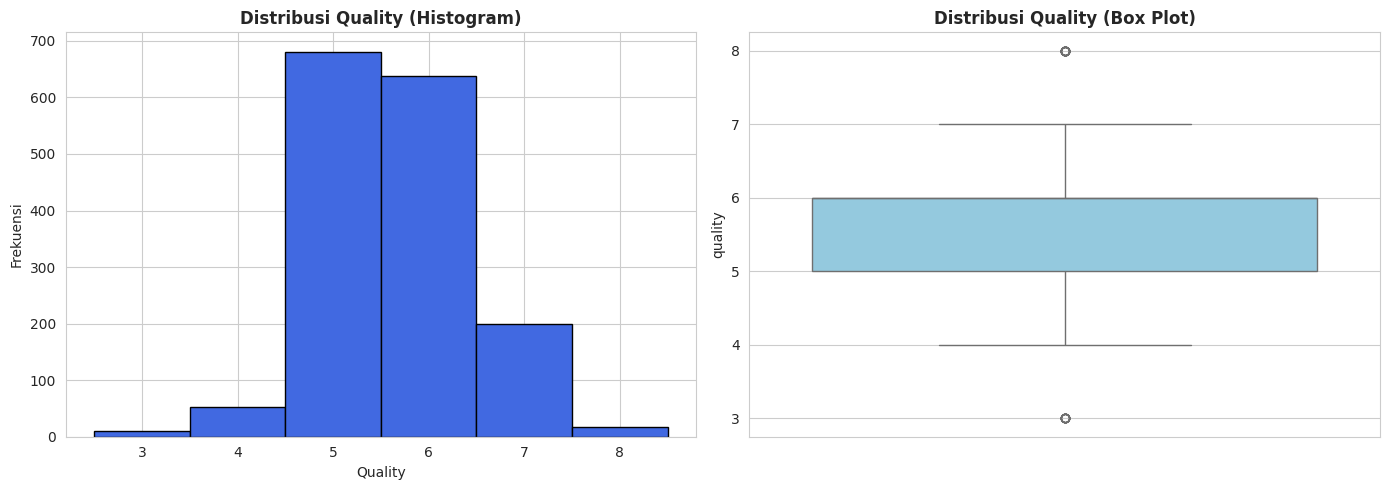

In [19]:
# Visualisasi Distribusi Quality (Digabungkan dalam 1 cell agar tidak error)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Histogram
df['quality'].hist(bins=range(3, 10), ax=axes[0], edgecolor='black', align='left', color='royalblue')
axes[0].set_title('Distribusi Quality (Histogram)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Quality')
axes[0].set_ylabel('Frekuensi')

# 2. Box plot
sns.boxplot(y=df['quality'], ax=axes[1], color='skyblue')
axes[1].set_title('Distribusi Quality (Box Plot)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


### Korelasi Antar Fitur (Pearson)
quality                 1.000000
alcohol                 0.476166
sulphates               0.251397
citric acid             0.226373
fixed acidity           0.124052
residual sugar          0.013732
free sulfur dioxide    -0.050656
pH                     -0.057731
chlorides              -0.128907
density                -0.174919
total sulfur dioxide   -0.185100
volatile acidity       -0.390558
Name: quality, dtype: float64


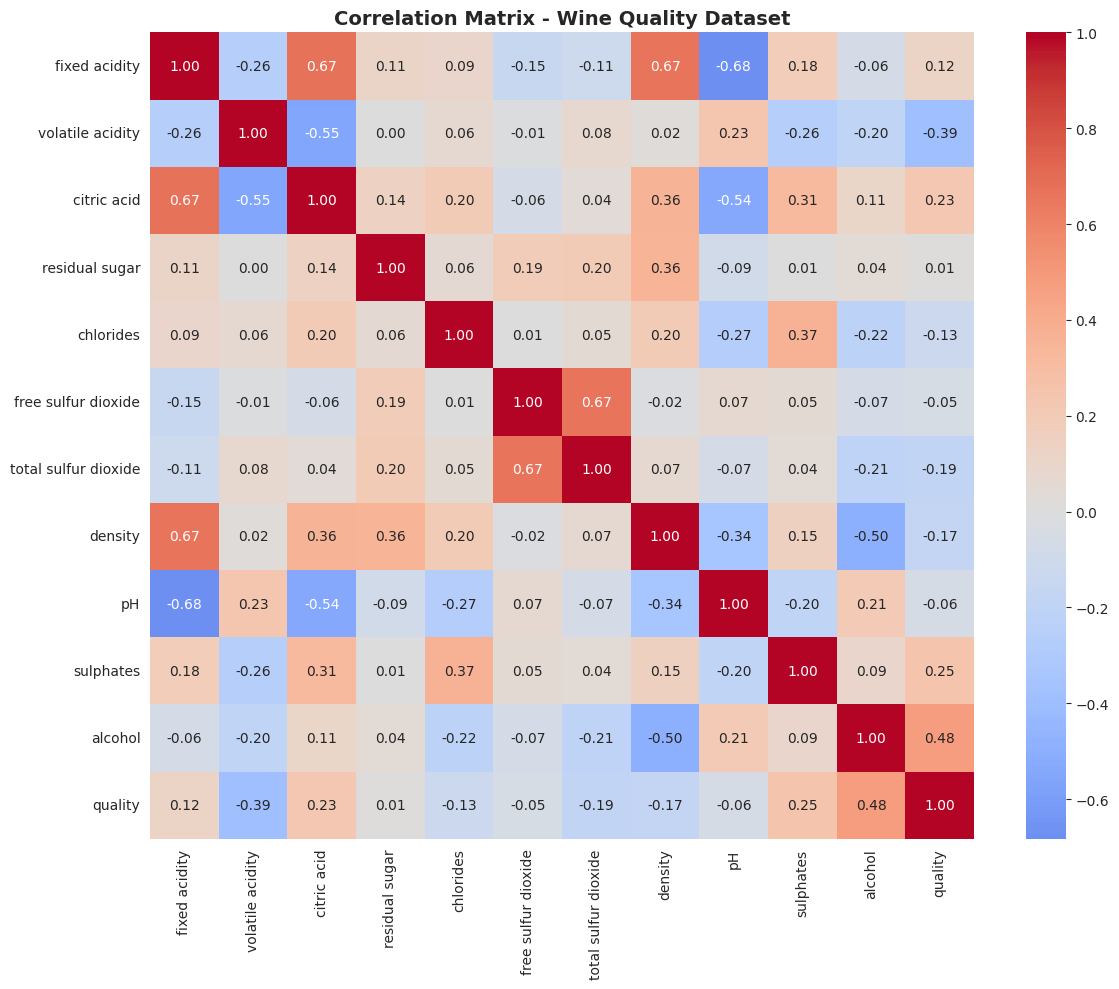

In [22]:
# 4.5 - Korelasi Antar Fitur
print("\n### Korelasi Antar Fitur (Pearson)")
correlation = df.corr()
print(correlation['quality'].sort_values(ascending=False))

# Visualisasi Heatmap Korelasi
plt.figure(figsize=(12, 10))
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix - Wine Quality Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [23]:
# 4.6 - Deteksi Outliers menggunakan IQR
print("\n### Deteksi Outliers (IQR Method)")
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

outliers_mask = ((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)
print(f"Total outliers: {outliers_mask.sum()}")
print(f"Persentase outliers: {(outliers_mask.sum() / len(df)) * 100:.2f}%")


### Deteksi Outliers (IQR Method)
Total outliers: 420
Persentase outliers: 26.27%


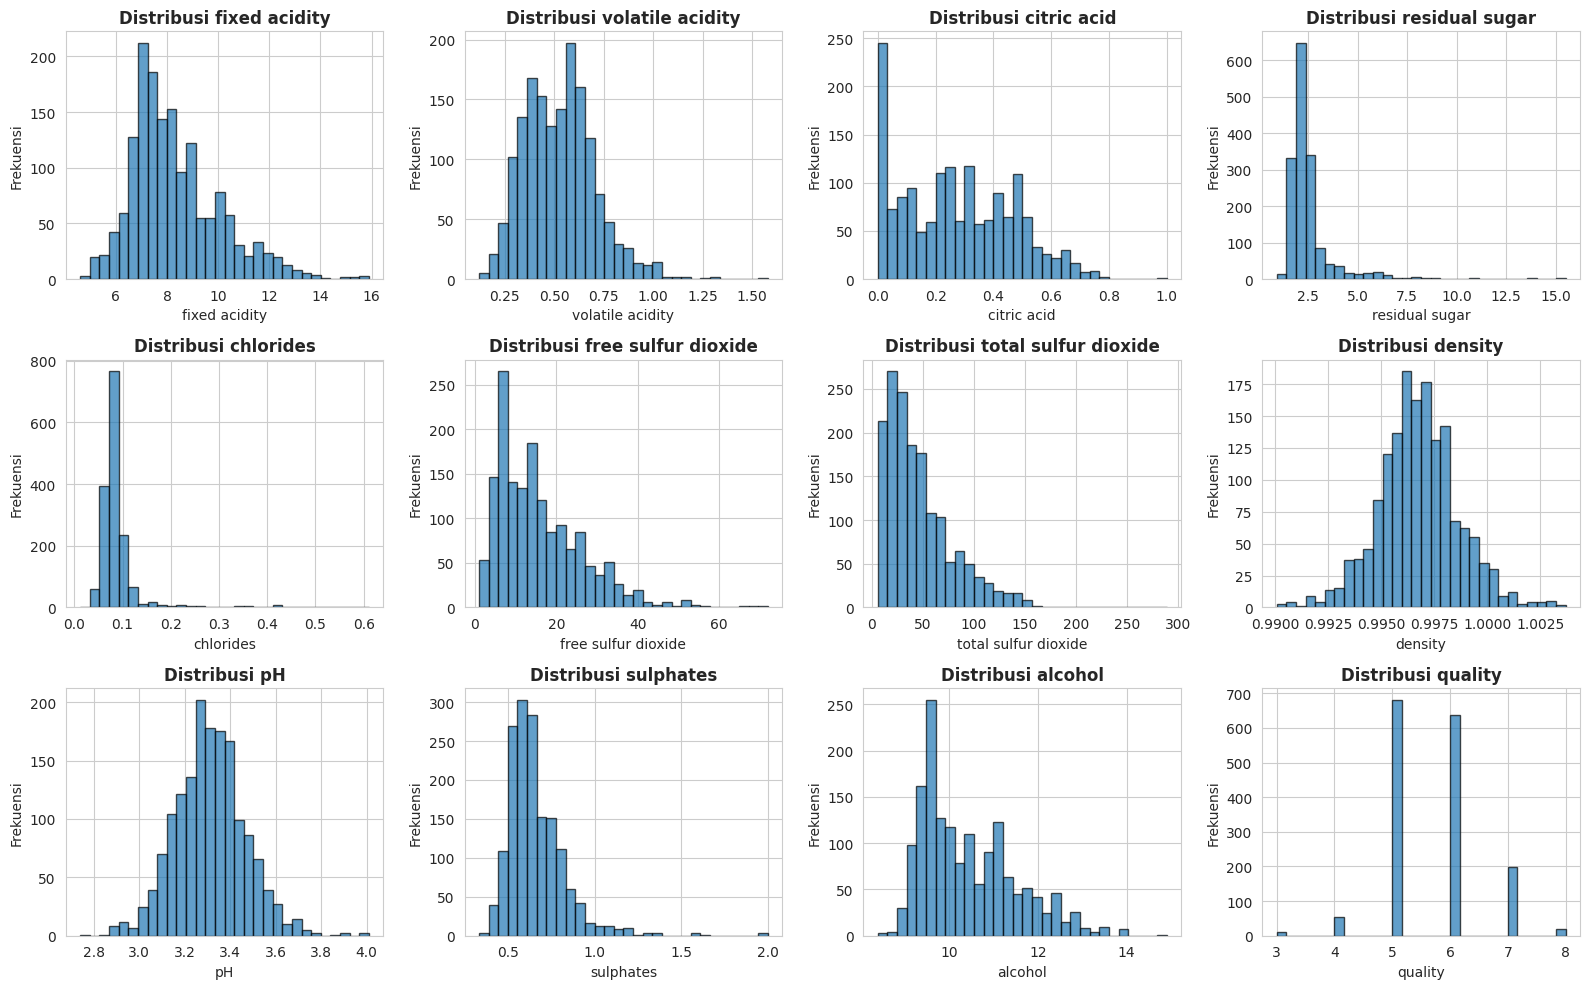

In [24]:
# 4.7 - Distribusi Setiap Fitur
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.ravel()

numeric_cols = df.select_dtypes(include=[np.number]).columns
for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=30, edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribusi {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()


# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [25]:
print("\n" + "=" * 60)
print("DATA PREPROCESSING")
print("=" * 60)

# 5.1 - Handle Missing Values
print("\n### 1. Handling Missing Values")
# Cek missing values
missing_before = df.isnull().sum().sum()
print(f"Missing values sebelum: {missing_before}")

# Jika ada missing values, fill dengan median
if missing_before > 0:
    df_clean = df.fillna(df.median(numeric_only=True))
    missing_after = df_clean.isnull().sum().sum()
    print(f"Missing values sesudah: {missing_after}")
else:
    df_clean = df.copy()
    print("Tidak ada missing values")


DATA PREPROCESSING

### 1. Handling Missing Values
Missing values sebelum: 0
Tidak ada missing values


In [26]:
# 5.2 - Handle Duplikat
print("\n### 2. Menghapus Data Duplikat")
duplicates_before = df_clean.duplicated().sum()
print(f"Duplikat sebelum: {duplicates_before}")

df_clean = df_clean.drop_duplicates()
duplicates_after = df_clean.duplicated().sum()
print(f"Duplikat sesudah: {duplicates_after}")
print(f"Data rows setelah cleaning: {df_clean.shape[0]}")


### 2. Menghapus Data Duplikat
Duplikat sebelum: 240
Duplikat sesudah: 0
Data rows setelah cleaning: 1359


In [27]:
# 5.3 - Handle Outliers (Optional - Bisa dihapus atau di-retain)
print("\n### 3. Deteksi Outliers")
print("Catatan: Outliers di-retain (tidak dihapus) karena mungkin data valid")


### 3. Deteksi Outliers
Catatan: Outliers di-retain (tidak dihapus) karena mungkin data valid


In [28]:
# 5.4 - Separasi Feature dan Target
print("\n### 4. Separasi Feature dan Target")
X = df_clean.drop('quality', axis=1)
y = df_clean['quality']

print(f"Shape X (features): {X.shape}")
print(f"Shape y (target): {y.shape}")
print(f"\nNama fitur: {X.columns.tolist()}")


### 4. Separasi Feature dan Target
Shape X (features): (1359, 11)
Shape y (target): (1359,)

Nama fitur: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


In [29]:
# 5.5 - Normalisasi/Standarisasi Fitur
print("\n### 5. Standarisasi Fitur")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("Statistik X setelah scaling:")
print(X_scaled_df.describe())


### 5. Standarisasi Fitur
Statistik X setelah scaling:
       fixed acidity  volatile acidity   citric acid  residual sugar  \
count   1.359000e+03      1.359000e+03  1.359000e+03    1.359000e+03   
mean   -6.274108e-16      1.463959e-16  2.091369e-17   -1.202537e-16   
std     1.000368e+00      1.000368e+00  1.000368e+00    1.000368e+00   
min    -2.137008e+00     -2.238023e+00 -1.393258e+00   -1.200903e+00   
25%    -6.972071e-01     -7.623226e-01 -9.328165e-01   -4.611571e-01   
50%    -2.364707e-01     -5.180013e-02 -6.309377e-02   -2.392334e-01   
75%     5.122260e-01      6.040667e-01  8.066290e-01    5.666484e-02   
max     4.370894e+00      5.741690e+00  3.722758e+00    9.599383e+00   

          chlorides  free sulfur dioxide  total sulfur dioxide       density  \
count  1.359000e+03         1.359000e+03          1.359000e+03  1.359000e+03   
mean   4.182739e-17        -8.365477e-17          4.182739e-17  5.286982e-14   
std    1.000368e+00         1.000368e+00          1.000

In [30]:
# 5.6 - Split Train-Test
print("\n### 6. Split Train-Test")
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_df, y, test_size=0.2, random_state=42
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")


### 6. Split Train-Test
X_train shape: (1087, 11)
X_test shape: (272, 11)
y_train shape: (1087,)
y_test shape: (272,)


In [32]:
import os

print("\n" + "=" * 60)
print("### 7. Menyimpan Dataset Preprocessing")
print("=" * 60)

# Definisikan direktori target penyimpanan di Google Drive
target_dir = '/content/drive/MyDrive/Colab Notebooks/DICODING AWS MACHINE LEARNING/LEVEL EXPERT'

# Membuat direktori jika belum ada
os.makedirs(target_dir, exist_ok=True)

# Menentukan path lengkap file tujuan
preprocessed_features_path = os.path.join(target_dir, 'wine_quality_preprocessed.csv')
preprocessed_target_path = os.path.join(target_dir, 'wine_quality_target.csv')

# Menyimpan dataset ke target path
X_scaled_df.to_csv(preprocessed_features_path, index=False)
y.to_csv(preprocessed_target_path, index=False)

print(f"✓ Dataset preprocessed berhasil disimpan ke:\n  - {preprocessed_features_path}\n  - {preprocessed_target_path}")

print("\n" + "=" * 60)
print("PREPROCESSING SELESAI")
print("=" * 60)


### 7. Menyimpan Dataset Preprocessing
✓ Dataset preprocessed berhasil disimpan ke:
  - /content/drive/MyDrive/Colab Notebooks/DICODING AWS MACHINE LEARNING/LEVEL EXPERT/wine_quality_preprocessed.csv
  - /content/drive/MyDrive/Colab Notebooks/DICODING AWS MACHINE LEARNING/LEVEL EXPERT/wine_quality_target.csv

PREPROCESSING SELESAI
